In [88]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics


In [89]:
data = pd.read_csv("insurance.csv")

In [90]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [91]:
data.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [92]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [93]:
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [94]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [95]:
print(data['sex'].value_counts())
print(data['smoker'].value_counts())
print(data['region'].value_counts())

sex
male      676
female    662
Name: count, dtype: int64
smoker
no     1064
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


In [96]:
data.shape

(1338, 7)

C:\Users\HP\AppData\Local\Temp\ipykernel_8292\467262280.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['age'])


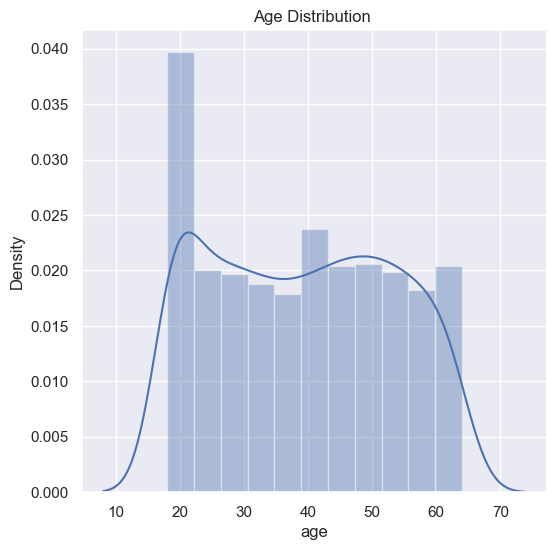

In [97]:
sns.set()
plt.figure(figsize=(6,6))
sns.distplot(data['age'])
plt.title('Age Distribution ')
plt.show()

In [98]:
## Encoding the object column 
data.replace({'sex': {'male': 0,'female':1}}, inplace=True)
data.replace({'smoker': {'no': 0,'yes':1}}, inplace=True)
data.replace({'region': {'southeast': 0,'southwest':1, 'northeast':2, 'northwest':3}}, inplace=True)


C:\Users\HP\AppData\Local\Temp\ipykernel_8292\1415794369.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace({'sex': {'male': 0,'female':1}}, inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_8292\1415794369.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace({'smoker': {'no': 0,'yes':1}}, inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_8292\1415794369.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, expli

In [99]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,1,16884.92400
1,18,0,33.770,1,0,0,1725.55230
2,28,0,33.000,3,0,0,4449.46200
3,33,0,22.705,0,0,3,21984.47061
4,32,0,28.880,0,0,3,3866.85520


In [100]:
## Splitting features and target 
X =  data.drop(columns='charges',axis=1)
Y =  data['charges']

In [101]:
## Splitting into test train split
X_train , X_test , Y_train, Y_test = train_test_split(X , Y, test_size=0.2, random_state=42)

In [102]:
model = LinearRegression()

In [103]:
model.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [104]:
## Model Evaluation and prediction

Train_pred = model.predict(X_train)

Train_score = metrics.r2_score(Y_train , Train_pred)

Train_score

0.7413131194887537

In [105]:
## Testing evaluation and prediction

Test_pred = model.predict(X_test)

Test_score = metrics.r2_score(Y_test , Test_pred)

Test_score

0.783021587162344

In [109]:
##Build a predictive system 
input_data = [37,"female",27.74,3,"no","northwest"]

input_data = pd.DataFrame(
    [input_data],
    columns=['age', 'sex', 'bmi', 'children', 'smoker', 'region']
)

## Encoding the object column 
input_data.replace({'sex': {'male': 0,'female':1}}, inplace=True)
input_data.replace({'smoker': {'no': 0,'yes':1}}, inplace=True)
input_data.replace({'region': {'southeast': 0,'southwest':1, 'northeast':2, 'northwest':3}}, inplace=True)

## Making it a np array
input_data_as_np_array = np.asarray(input_data)

input_data_reshaped = input_data_as_np_array.reshape(1, -1)

Prediction = model.predict(input_data_reshaped)

print(f"The model has predicted the value of the insurance : {Prediction} ")

The model has predicted the value of the insurance : [7992.23301725] 


C:\Users\HP\AppData\Local\Temp\ipykernel_8292\2766078088.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  input_data.replace({'sex': {'male': 0,'female':1}}, inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_8292\2766078088.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  input_data.replace({'smoker': {'no': 0,'yes':1}}, inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_8292\2766078088.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old 